# Distancias

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from scipy.spatial import distance_matrix
import pandas as pd

In [3]:
data = pd.read_csv("/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/movies/movies.csv", sep = ';')

In [4]:
data

,user_id,star_wars,lord_of_the_rings,harry_potter
0,1,1.2,4.9,2.1
1,2,2.1,8.1,7.9
2,3,7.4,3.0,9.9
3,4,5.6,0.5,1.8
4,5,1.5,8.3,2.6
5,6,2.5,3.7,6.5
6,7,2.0,8.2,8.5
7,8,1.8,9.3,4.5
8,9,2.6,1.7,3.1
9,10,1.5,4.7,2.3


In [5]:
movies_list = data.columns.values.tolist()[1:]
movies_list

['star_wars', 'lord_of_the_rings', 'harry_potter']

### Conociendo como usar la distancia de Minkowsky

In [6]:
# dd = matriz de distancias

dd1 = distance_matrix(data[movies_list], data[movies_list], p = 1) # Distancia de Manhattan
dd2 = distance_matrix(data[movies_list], data[movies_list], p = 2) # Distancia Euclídea
dd10 = distance_matrix(data[movies_list], data[movies_list], p = 10)

In [7]:
dd1 # Resulta incómodo visualizar la información de esta manera

array([[ 0. ,  9.9, 15.9,  9.1,  4.2,  6.9, 10.5,  7.4,  5.6,  0.7],
       [ 9.9,  0. , 12.4, 17.2,  6.1,  6.2,  0.8,  4.9, 11.7,  9.6],
       [15.9, 12.4,  0. , 12.4, 18.5,  9. , 12. , 17.3, 12.9, 15.2],
       [ 9.1, 17.2, 12.4,  0. , 12.7, 11. , 18. , 15.3,  5.5,  8.8],
       [ 4.2,  6.1, 18.5, 12.7,  0. ,  9.5,  6.5,  3.2,  8.2,  3.9],
       [ 6.9,  6.2,  9. , 11. ,  9.5,  0. ,  7. ,  8.3,  5.5,  6.2],
       [10.5,  0.8, 12. , 18. ,  6.5,  7. ,  0. ,  5.3, 12.5, 10.2],
       [ 7.4,  4.9, 17.3, 15.3,  3.2,  8.3,  5.3,  0. ,  9.8,  7.1],
       [ 5.6, 11.7, 12.9,  5.5,  8.2,  5.5, 12.5,  9.8,  0. ,  4.9],
       [ 0.7,  9.6, 15.2,  8.8,  3.9,  6.2, 10.2,  7.1,  4.9,  0. ]])

#### Crearemos una función para transformar dd1, dd2, dd10 a DataFrames:

In [8]:
def dd_to_df(dd, column_id_user): # column_id_user se refiere a los valores del id_user de data (data['id_user'])
    import pandas as pandas
    return pd.DataFrame(dd, index = column_id_user, columns = column_id_user)

In [9]:
dd_to_df(dd1, data['user_id'])

user_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,0.0,9.9,15.9,9.1,4.2,6.9,10.5,7.4,5.6,0.7
2,9.9,0.0,12.4,17.2,6.1,6.2,0.8,4.9,11.7,9.6
3,15.9,12.4,0.0,12.4,18.5,9.0,12.0,17.3,12.9,15.2
4,9.1,17.2,12.4,0.0,12.7,11.0,18.0,15.3,5.5,8.8
5,4.2,6.1,18.5,12.7,0.0,9.5,6.5,3.2,8.2,3.9
6,6.9,6.2,9.0,11.0,9.5,0.0,7.0,8.3,5.5,6.2
7,10.5,0.8,12.0,18.0,6.5,7.0,0.0,5.3,12.5,10.2
8,7.4,4.9,17.3,15.3,3.2,8.3,5.3,0.0,9.8,7.1
9,5.6,11.7,12.9,5.5,8.2,5.5,12.5,9.8,0.0,4.9


In [10]:
dd_to_df(dd2, data['user_id'])

user_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,0.000000,6.685058,10.143471,6.229767,3.449638,4.742362,7.244998,5.047772,3.633180,0.412311
2,6.685058,0.000000,7.622336,10.354709,5.337602,4.634652,0.616441,3.618011,8.015610,6.578754
3,10.143471,7.622336,0.000000,8.666026,10.779147,6.004998,7.626270,10.010494,8.424369,9.770363
4,6.229767,10.354709,8.666026,0.000000,8.848164,6.476110,10.823123,9.958414,3.482815,5.890671
5,3.449638,5.337602,10.779147,8.848164,0.000000,6.113101,5.921993,2.167948,6.709694,3.612478
6,4.742362,4.634652,6.004998,6.476110,6.113101,0.000000,4.949747,5.987487,3.945884,4.431704
7,7.244998,0.616441,7.626270,10.823123,5.921993,4.949747,0.000000,4.153312,8.471718,7.137226
8,5.047772,3.618011,10.010494,9.958414,2.167948,5.987487,4.153312,0.000000,7.769170,5.107837
9,3.633180,8.015610,8.424369,3.482815,6.709694,3.945884,8.471718,7.769170,0.000000,3.293934


In [11]:
dd_to_df(dd10, data['user_id'])

user_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,0.000000,5.801514,7.875189,4.715803,3.400000,4.400003,6.400850,4.401025,3.200085,0.301025
2,5.801514,0.000000,5.582463,7.680689,5.300000,4.400005,0.600000,3.400010,6.435159,5.603800
3,7.875189,5.582463,0.000000,8.100007,7.408914,4.912532,5.689450,6.570254,6.820602,7.658364
4,4.715803,7.680689,8.100007,0.000000,7.801255,4.717102,7.873307,8.800205,3.000101,4.450759
5,3.400000,5.300000,7.408914,7.801255,0.000000,4.681464,5.900000,1.900310,6.600000,3.600000
6,4.400003,4.400005,4.912532,4.717102,4.681464,0.000000,4.500135,5.600019,3.401683,4.200000
7,6.400850,0.600000,5.689450,7.873307,5.900000,4.500135,0.000000,4.000001,6.595259,6.202035
8,4.401025,3.400010,6.570254,8.800205,1.900310,5.600019,4.000001,0.000000,7.600000,4.600288
9,3.200085,6.435159,6.820602,3.000101,6.600000,3.401683,6.595259,7.600000,0.000000,3.000014


### Representemos información de interés en gráficas 3D

In [12]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

Text(0.5, 0, 'harry_potter')

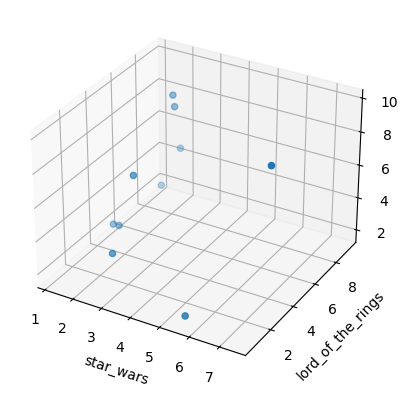

In [13]:
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(xs = data['star_wars'], ys = data['lord_of_the_rings'], zs = data['harry_potter'])
ax.set_xlabel('star_wars')
ax.set_ylabel('lord_of_the_rings')
ax.set_zlabel('harry_potter')

# Enlaces

In [14]:
df = dd_to_df(dd1, data['user_id']) # Dataframe a partir de la distancia de Manhatann

In [15]:
df

user_id,1,2,3,4,5,6,7,8,9,10
user_id,,,,,,,,,,
1,0.0,9.9,15.9,9.1,4.2,6.9,10.5,7.4,5.6,0.7
2,9.9,0.0,12.4,17.2,6.1,6.2,0.8,4.9,11.7,9.6
3,15.9,12.4,0.0,12.4,18.5,9.0,12.0,17.3,12.9,15.2
4,9.1,17.2,12.4,0.0,12.7,11.0,18.0,15.3,5.5,8.8
5,4.2,6.1,18.5,12.7,0.0,9.5,6.5,3.2,8.2,3.9
6,6.9,6.2,9.0,11.0,9.5,0.0,7.0,8.3,5.5,6.2
7,10.5,0.8,12.0,18.0,6.5,7.0,0.0,5.3,12.5,10.2
8,7.4,4.9,17.3,15.3,3.2,8.3,5.3,0.0,9.8,7.1
9,5.6,11.7,12.9,5.5,8.2,5.5,12.5,9.8,0.0,4.9


#### Viendo la matriz anterior, la distancia menor viene dada entre los `id = 1` e `id = 10`. Tomaremos esta distancia inicialmente.

In [16]:
Z = []

In [17]:
df[11] = df[1] + df[10]
df.loc[11] = df.loc[1] + df.loc[10]
Z.append([1, 10, 0.7, 2]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 11
df

user_id,1,2,3,4,5,6,7,8,9,10,11
user_id,,,,,,,,,,,
1,0.0,9.9,15.9,9.1,4.2,6.9,10.5,7.4,5.6,0.7,0.7
2,9.9,0.0,12.4,17.2,6.1,6.2,0.8,4.9,11.7,9.6,19.5
3,15.9,12.4,0.0,12.4,18.5,9.0,12.0,17.3,12.9,15.2,31.1
4,9.1,17.2,12.4,0.0,12.7,11.0,18.0,15.3,5.5,8.8,17.9
5,4.2,6.1,18.5,12.7,0.0,9.5,6.5,3.2,8.2,3.9,8.1
6,6.9,6.2,9.0,11.0,9.5,0.0,7.0,8.3,5.5,6.2,13.1
7,10.5,0.8,12.0,18.0,6.5,7.0,0.0,5.3,12.5,10.2,20.7
8,7.4,4.9,17.3,15.3,3.2,8.3,5.3,0.0,9.8,7.1,14.5
9,5.6,11.7,12.9,5.5,8.2,5.5,12.5,9.8,0.0,4.9,10.5


In [18]:
for i in df.columns.values.tolist():
    df.loc[11][i] = min(df.loc[1][i], df.loc[10][i])
    df.loc[i][11] = min(df.loc[i][1], df.loc[i][10])

In [19]:
df

user_id,1,2,3,4,5,6,7,8,9,10,11
user_id,,,,,,,,,,,
1,0.0,9.9,15.9,9.1,4.2,6.9,10.5,7.4,5.6,0.7,0.0
2,9.9,0.0,12.4,17.2,6.1,6.2,0.8,4.9,11.7,9.6,9.6
3,15.9,12.4,0.0,12.4,18.5,9.0,12.0,17.3,12.9,15.2,15.2
4,9.1,17.2,12.4,0.0,12.7,11.0,18.0,15.3,5.5,8.8,8.8
5,4.2,6.1,18.5,12.7,0.0,9.5,6.5,3.2,8.2,3.9,3.9
6,6.9,6.2,9.0,11.0,9.5,0.0,7.0,8.3,5.5,6.2,6.2
7,10.5,0.8,12.0,18.0,6.5,7.0,0.0,5.3,12.5,10.2,10.2
8,7.4,4.9,17.3,15.3,3.2,8.3,5.3,0.0,9.8,7.1,7.1
9,5.6,11.7,12.9,5.5,8.2,5.5,12.5,9.8,0.0,4.9,4.9


In [20]:
df = df.drop([1, 10])
df = df.drop([1, 10], axis = 1)

In [21]:
df

user_id,2,3,4,5,6,7,8,9,11
user_id,,,,,,,,,
2,0.0,12.4,17.2,6.1,6.2,0.8,4.9,11.7,9.6
3,12.4,0.0,12.4,18.5,9.0,12.0,17.3,12.9,15.2
4,17.2,12.4,0.0,12.7,11.0,18.0,15.3,5.5,8.8
5,6.1,18.5,12.7,0.0,9.5,6.5,3.2,8.2,3.9
6,6.2,9.0,11.0,9.5,0.0,7.0,8.3,5.5,6.2
7,0.8,12.0,18.0,6.5,7.0,0.0,5.3,12.5,10.2
8,4.9,17.3,15.3,3.2,8.3,5.3,0.0,9.8,7.1
9,11.7,12.9,5.5,8.2,5.5,12.5,9.8,0.0,4.9
11,9.6,15.2,8.8,3.9,6.2,10.2,7.1,4.9,0.0


#### De esta nueva matriz, revisamos nuevamente cuál es la distancia más pequeña, en este caso, es 0.8, para los id = 2 e id = 7.

In [22]:
x = 2
y = 7
n = 12

df[n] = df[x] + df[y]
df.loc[n] = df.loc[x] + df.loc[y]
Z.append([x, y, df.loc[x][y], 2]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 12

for i in df.columns.values.tolist():
    df.loc[n][i] = min(df.loc[x][i], df.loc[y][i])
    df.loc[i][n] = min(df.loc[i][x], df.loc[i][y])

df = df.drop([x, y])
df = df.drop([x, y], axis = 1)

df

user_id,3,4,5,6,8,9,11,12
user_id,,,,,,,,
3,0.0,12.4,18.5,9.0,17.3,12.9,15.2,12.0
4,12.4,0.0,12.7,11.0,15.3,5.5,8.8,17.2
5,18.5,12.7,0.0,9.5,3.2,8.2,3.9,6.1
6,9.0,11.0,9.5,0.0,8.3,5.5,6.2,6.2
8,17.3,15.3,3.2,8.3,0.0,9.8,7.1,4.9
9,12.9,5.5,8.2,5.5,9.8,0.0,4.9,11.7
11,15.2,8.8,3.9,6.2,7.1,4.9,0.0,9.6
12,12.0,17.2,6.1,6.2,4.9,11.7,9.6,0.0


#### Continuamos de manera iterativa. En esta matriza de arriba, la distancia menor es d = 3.2, de los id = 5 e id = 8.

In [23]:
x = 5
y = 8
n = 13

df[n] = df[x] + df[y]
df.loc[n] = df.loc[x] + df.loc[y]
Z.append([x, y, df.loc[x][y], 2]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 13

for i in df.columns.values.tolist():
    df.loc[n][i] = min(df.loc[x][i], df.loc[y][i])
    df.loc[i][n] = min(df.loc[i][x], df.loc[i][y])

df = df.drop([x, y])
df = df.drop([x, y], axis = 1)

df

user_id,3,4,6,9,11,12,13
user_id,,,,,,,
3,0.0,12.4,9.0,12.9,15.2,12.0,17.3
4,12.4,0.0,11.0,5.5,8.8,17.2,12.7
6,9.0,11.0,0.0,5.5,6.2,6.2,8.3
9,12.9,5.5,5.5,0.0,4.9,11.7,8.2
11,15.2,8.8,6.2,4.9,0.0,9.6,3.9
12,12.0,17.2,6.2,11.7,9.6,0.0,4.9
13,17.3,12.7,8.3,8.2,3.9,4.9,0.0


#### Seguimos

In [24]:
x = 11
y = 13
n = 14

df[n] = df[x] + df[y]
df.loc[n] = df.loc[x] + df.loc[y]
Z.append([x, y, df.loc[x][y], 2]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 14

for i in df.columns.values.tolist():
    df.loc[n][i] = min(df.loc[x][i], df.loc[y][i])
    df.loc[i][n] = min(df.loc[i][x], df.loc[i][y])

df = df.drop([x, y])
df = df.drop([x, y], axis = 1)

df

user_id,3,4,6,9,12,14
user_id,,,,,,
3,0.0,12.4,9.0,12.9,12.0,15.2
4,12.4,0.0,11.0,5.5,17.2,8.8
6,9.0,11.0,0.0,5.5,6.2,6.2
9,12.9,5.5,5.5,0.0,11.7,4.9
12,12.0,17.2,6.2,11.7,0.0,4.9
14,15.2,8.8,6.2,4.9,4.9,0.0


### NOTA IMPORTANTE:
#### En la matriz de arriba, hay tres id involucrados en la menor distancia d = 4.9, es decir, id = 9, id = 12, id = 14. Modificaremos el código según este caso.

In [25]:
'''
Aquí debemos notar que los pares de ids que determinan la distancia d = 4.9, son ids = 9, 14
y ids = 12, 14. Así que haremos x = 9, y = 14, y z = 12, para que la creación de las nuevas filas
y columnas se haga de manera correcta.
'''

x = 9
y = 14
z = 12 # Nuevo id que entra en el análisis.
n = 15

df[n] = df[x] + df[y] + df[z]
df.loc[n] = df.loc[x] + df.loc[y] + df.loc[z]
Z.append([x, y, z, df.loc[x][y], 3]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 15

for i in df.columns.values.tolist():
    df.loc[n][i] = min(df.loc[x][i], df.loc[y][i], df.loc[z][i])
    df.loc[i][n] = min(df.loc[i][x], df.loc[i][y], df.loc[i][z])

df = df.drop([x, y, z])
df = df.drop([x, y, z], axis = 1)

df

user_id,3,4,6,15
user_id,,,,
3,0.0,12.4,9.0,12.0
4,12.4,0.0,11.0,5.5
6,9.0,11.0,0.0,5.5
15,12.0,5.5,5.5,0.0


In [26]:
x = 4
y = 6
z = 15 # Nuevo id que entra en el análisis.

n = 16

df[n] = df[x] + df[y] + df[z]
df.loc[n] = df.loc[x] + df.loc[y] + df.loc[z]
Z.append([x, y, z, df.loc[x][y], 3]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 16

for i in df.columns.values.tolist():
    df.loc[n][i] = min(df.loc[x][i], df.loc[y][i], df.loc[z][i])
    df.loc[i][n] = min(df.loc[i][x], df.loc[i][y], df.loc[i][z])

df = df.drop([x, y, z])
df = df.drop([x, y, z], axis = 1)

df

user_id,3,16
user_id,,
3,0.0,9.0
16,9.0,0.0


In [27]:
x = 3
y = 16

n = 17

df[n] = df[x] + df[y]
df.loc[n] = df.loc[x] + df.loc[y]
Z.append([x, y, df.loc[x][y], 2]) # id_1, id_2, distance, número de elementos del cluster; partida 2 elementos. --> 17

for i in df.columns.values.tolist():
    df.loc[n][i] = min(df.loc[x][i], df.loc[y][i])
    df.loc[i][n] = min(df.loc[i][x], df.loc[i][y])

df = df.drop([x, y])
df = df.drop([x, y], axis = 1)

df

user_id,17
user_id,
17,0.0


In [28]:
Z

[[1, 10, 0.7, 2],
 [2, 7, 0.7999999999999994, 2],
 [5, 8, 3.2, 2],
 [11, 13, 3.900000000000001, 2],
 [9, 14, 12, 4.9, 3],
 [4, 6, 15, 11.0, 3],
 [3, 16, 9.0, 2]]

# Clustering Jerárquico (con las herramientas de Python)

In [29]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [30]:
movies_list

['star_wars', 'lord_of_the_rings', 'harry_potter']

In [31]:
data[movies_list]

,star_wars,lord_of_the_rings,harry_potter
0,1.2,4.9,2.1
1,2.1,8.1,7.9
2,7.4,3.0,9.9
3,5.6,0.5,1.8
4,1.5,8.3,2.6
5,2.5,3.7,6.5
6,2.0,8.2,8.5
7,1.8,9.3,4.5
8,2.6,1.7,3.1
9,1.5,4.7,2.3


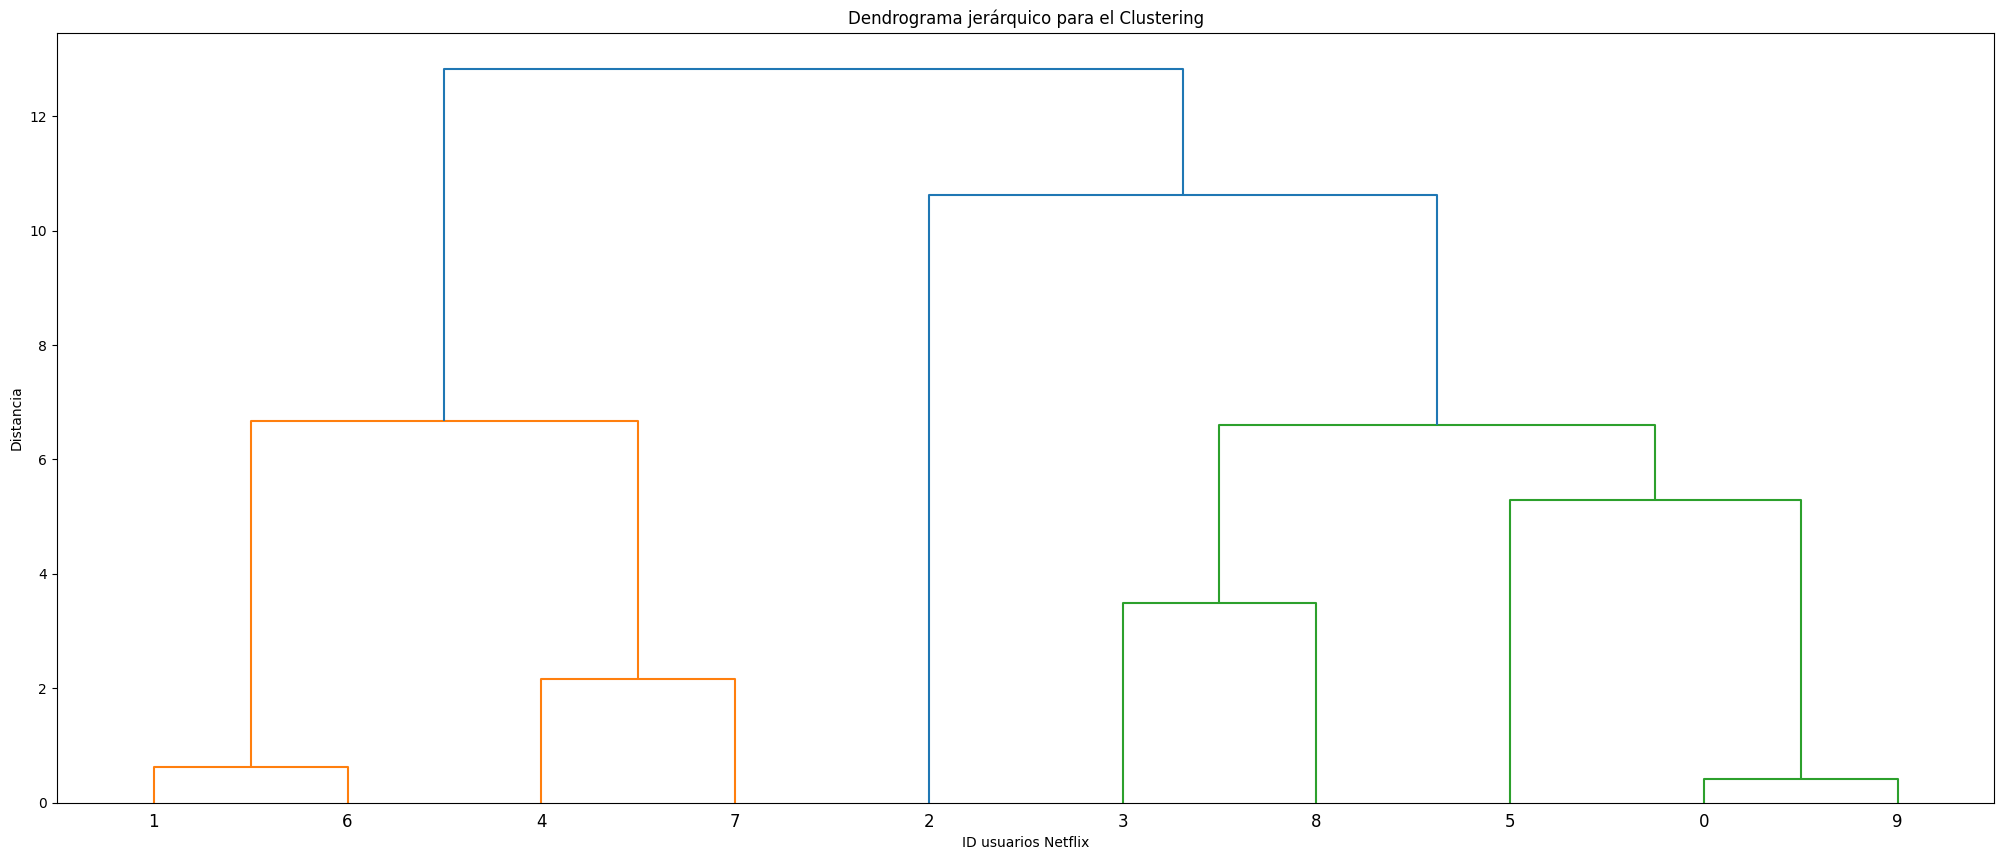

In [32]:
Z2 = linkage(data[movies_list], 'ward')
plt.figure(figsize = (25, 10))
plt.title('Dendrograma jerárquico para el Clustering')
plt.xlabel('ID usuarios Netflix')
plt.ylabel('Distancia')
dendrogram(Z2, leaf_rotation = 0, leaf_font_size = 12.0)
plt.show()

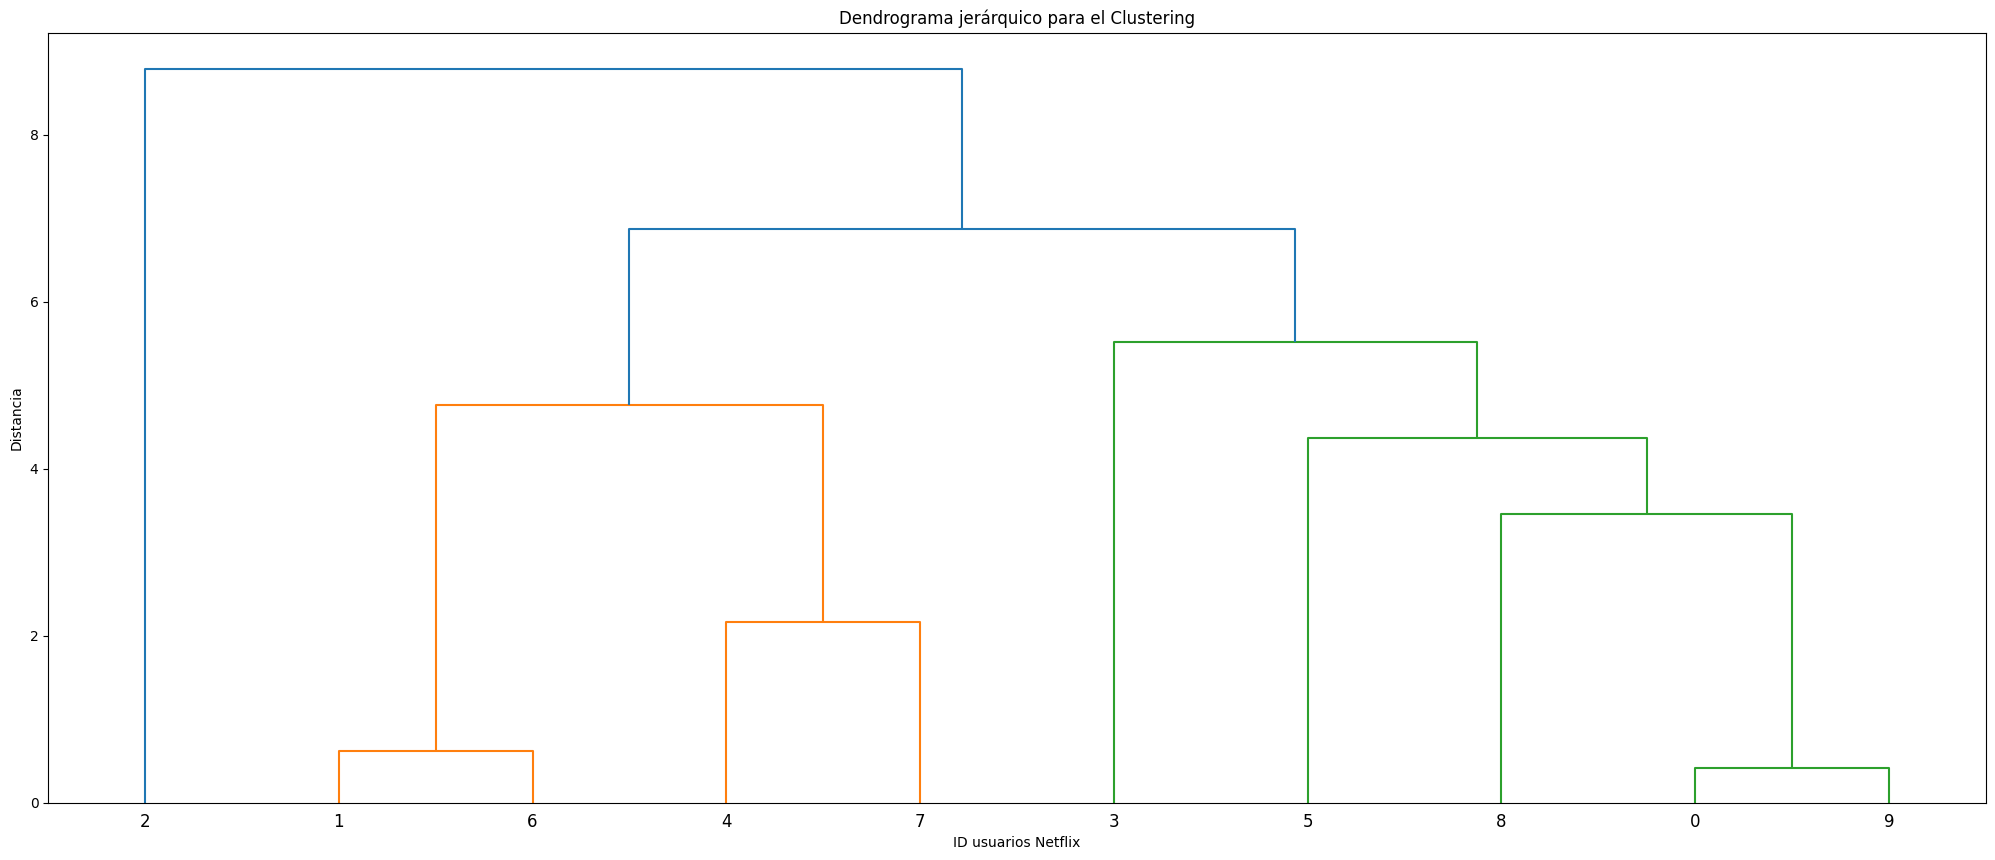

In [33]:
Z3 = linkage(data[movies_list], 'average')
plt.figure(figsize = (25, 10))
plt.title('Dendrograma jerárquico para el Clustering')
plt.xlabel('ID usuarios Netflix')
plt.ylabel('Distancia')
dendrogram(Z3, leaf_rotation = 0, leaf_font_size = 12.0)
plt.show()

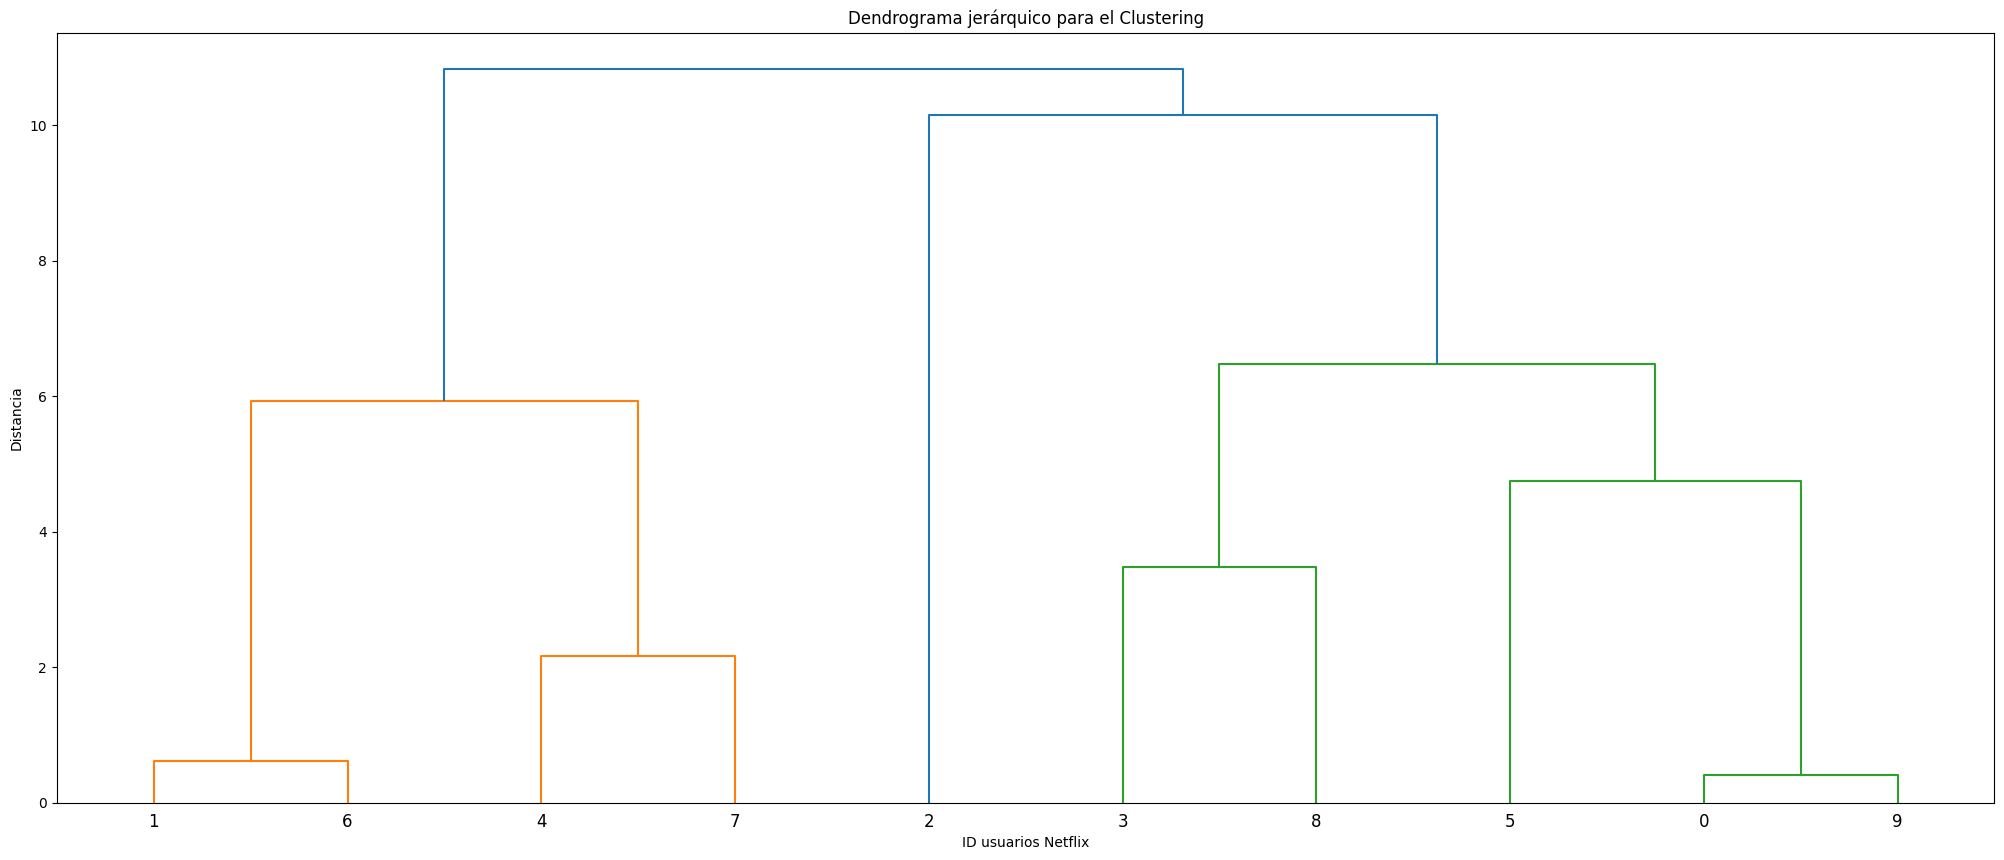

In [34]:
Z4 = linkage(data[movies_list], 'complete')
plt.figure(figsize = (25, 10))
plt.title('Dendrograma jerárquico para el Clustering')
plt.xlabel('ID usuarios Netflix')
plt.ylabel('Distancia')
dendrogram(Z4, leaf_rotation = 0, leaf_font_size = 12.0)
plt.show()

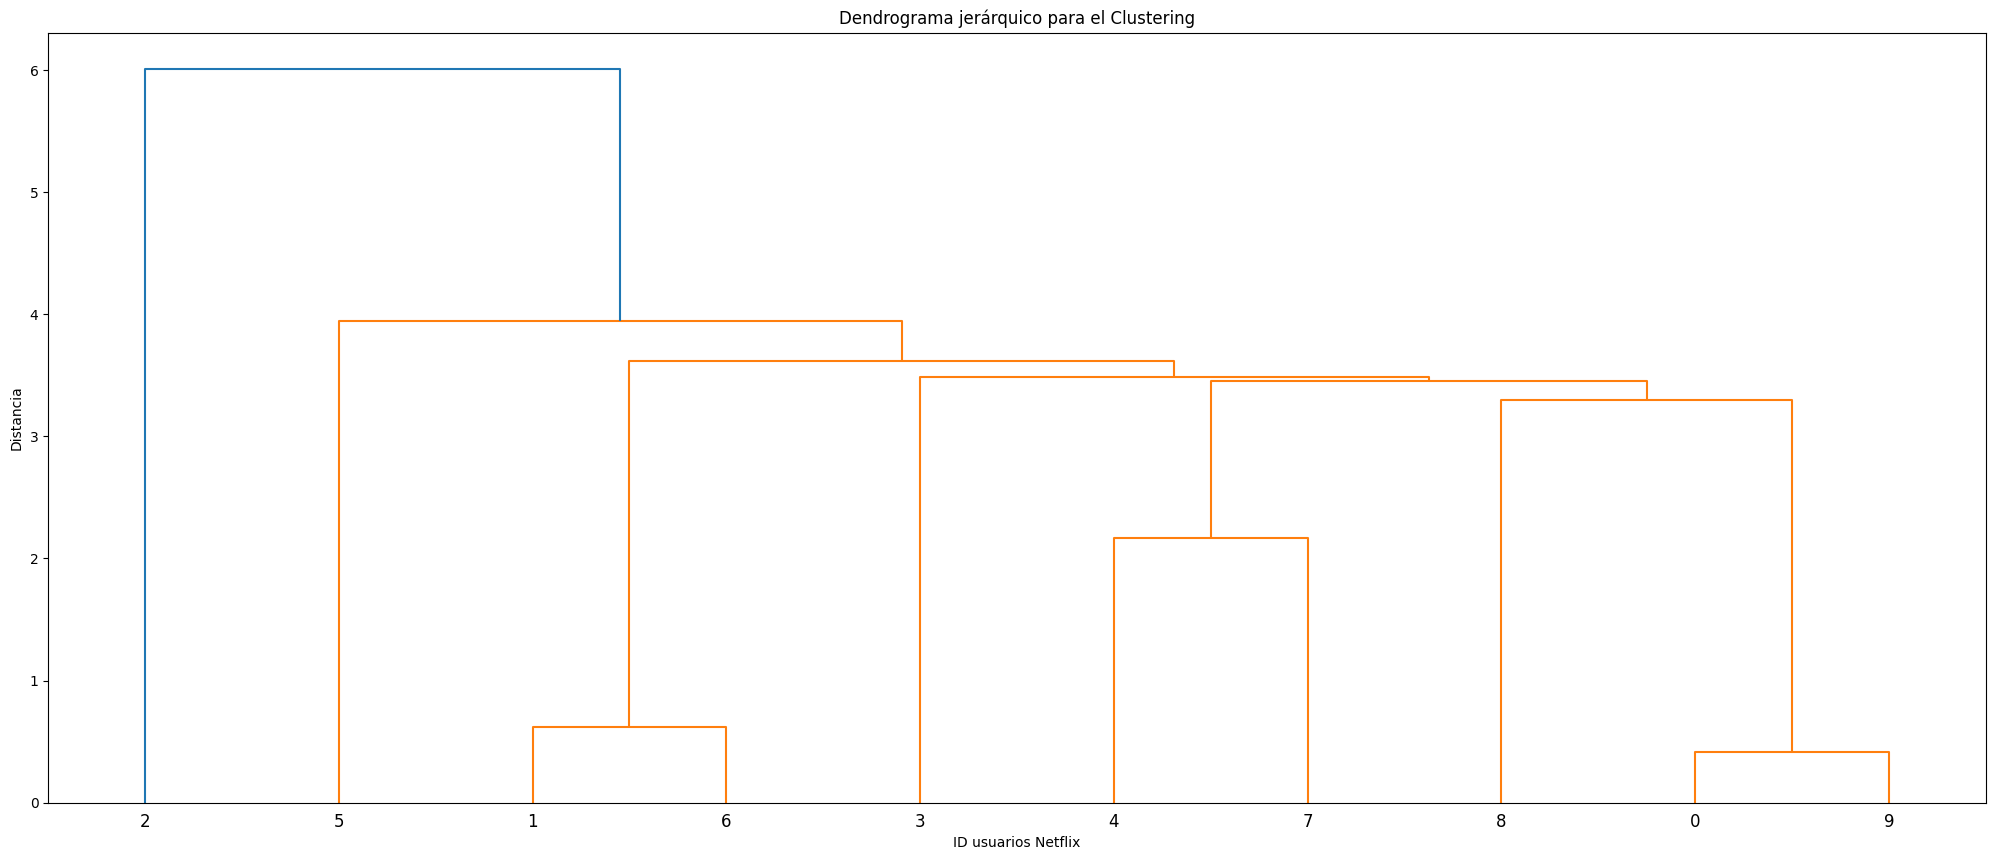

In [35]:
Z5 = linkage(data[movies_list], 'single')
plt.figure(figsize = (25, 10))
plt.title('Dendrograma jerárquico para el Clustering')
plt.xlabel('ID usuarios Netflix')
plt.ylabel('Distancia')
dendrogram(Z5, leaf_rotation = 0, leaf_font_size = 12.0)
plt.show()